# 06 — Deep Neural Network (DNN) en PyTorch

## 🎯 Objectif

Construire notre **premier modèle Deep Learning** pour la détection d'intrusion, en PyTorch, et le comparer à XGBoost.

**Question scientifique :** un DNN classique peut-il rivaliser avec XGBoost sur des données tabulaires de cybersécurité ?

## 📋 Plan

1. Setup et vérification GPU
2. Chargement + recréation des mêmes splits
3. **Normalisation** des features (essentielle en DL)
4. Conversion en tenseurs PyTorch + DataLoader
5. Définition de l'**architecture du DNN**
6. **Entraînement** avec early stopping
7. Évaluation sur validation, puis test
8. Comparaison avec XGBoost
9. Sauvegarde

## ⏱️ Temps estimé

**~10-20 minutes** sur ta RTX 4050 (le DL profite du GPU à fond).

## 1. Setup et vérification GPU

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
from pathlib import Path
from time import time

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score,
)

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')

# Chemins
DATA_PROCESSED = Path('../data/processed')
RESULTS_FIGURES = Path('../results/figures')
RESULTS_METRICS = Path('../results/metrics')
RESULTS_MODELS = Path('../results/models')

# Reproductibilité
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Vérifier le GPU
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ PyTorch : {torch.__version__}')
print(f'✅ Device  : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'✅ GPU     : {torch.cuda.get_device_name(0)}')
    print(f'✅ VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')

✅ PyTorch : 2.11.0+cu128
✅ Device  : cuda
✅ GPU     : NVIDIA GeForce RTX 4050 Laptop GPU
✅ VRAM    : 6.0 GB


## 2. Chargement des données et recréation des splits

In [2]:
df = pd.read_parquet(DATA_PROCESSED / 'cic-ids-2017_clean.parquet')

with open(DATA_PROCESSED / 'label_mapping.json') as f:
    label_mapping = json.load(f)
label_mapping = {int(k): v for k, v in label_mapping.items()}
class_names = [label_mapping[i] for i in sorted(label_mapping.keys())]
num_classes = len(class_names)

y = df['Label_encoded'].values
feature_cols = [c for c in df.columns if c not in ['Label', 'Label_encoded']]
X = df[feature_cols].values.astype(np.float32)   # ⭐ float32 pour PyTorch
num_features = X.shape[1]

# Même split que les notebooks 03-05
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.15/0.85,
    stratify=y_trainval, random_state=SEED
)

print(f'Features : {num_features}')
print(f'Classes  : {num_classes}')
print(f'Train    : {X_train.shape[0]:>10,}')
print(f'Val      : {X_val.shape[0]:>10,}')
print(f'Test     : {X_test.shape[0]:>10,}')

Features : 77
Classes  : 7
Train    :  1,762,512
Val      :    377,682
Test     :    377,682


## 3. Normalisation des features (ESSENTIEL pour le Deep Learning)

### 📚 Pourquoi c'est crucial ?

Les features ont des échelles très différentes :
- `Destination Port` va jusqu'à 65535
- `Flow Duration` va jusqu'à 120 000 000
- `FIN Flag Count` est 0 ou 1

Pour un réseau de neurones qui fait des multiplications matricielles, ces ordres de grandeur différents font que :
- Les gradients explosent ou disparaissent
- Le modèle se concentre uniquement sur les grandes features
- L'apprentissage est instable ou impossible

**Solution standard** : `StandardScaler` ramène toutes les features à moyenne=0, écart-type=1.

### ⚠️ Règle d'or : on **fit le scaler uniquement sur le train**

Pourquoi ? Si on incluait validation et test dans le calcul de la moyenne/écart-type, on créerait du **data leakage** (fuite d'information du test vers le train). On ne fait JAMAIS ça.

In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_val_scaled = scaler.transform(X_val).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

# Sauvegarder le scaler pour réutilisation
joblib.dump(scaler, RESULTS_MODELS / 'scaler_dnn.joblib')

print(f'Stats train scaled : mean={X_train_scaled.mean():.4f}, std={X_train_scaled.std():.4f}')
print(f'Stats val scaled   : mean={X_val_scaled.mean():.4f}, std={X_val_scaled.std():.4f}')
print(f'Stats test scaled  : mean={X_test_scaled.mean():.4f}, std={X_test_scaled.std():.4f}')

Stats train scaled : mean=0.0000, std=0.9466
Stats val scaled   : mean=0.0002, std=0.9271
Stats test scaled  : mean=0.0010, std=2.1572


Le train est exactement à (0, 1). Le val et test sont proches, légèrement différents — c'est **normal et sain** : si on avait obtenu exactement (0, 1) sur val/test, ce serait suspect (signe de data leakage).

## 4. Conversion en tenseurs PyTorch et DataLoaders

### 📚 Tenseurs PyTorch

Un tenseur est l'équivalent PyTorch d'un array NumPy, mais avec deux super-pouvoirs :
- Il peut vivre sur GPU (accélération massive)
- Il garde l'historique des calculs (pour la backpropagation)

### 📚 DataLoader

Le DataLoader gère :
- Le découpage en **batches** (par défaut 1024 lignes)
- Le **shuffle** des données à chaque epoch (important pour l'apprentissage)
- Le **chargement parallèle** en arrière-plan

C'est l'équivalent d'un buffet à volonté qui sert les données au modèle à mesure qu'il les digère.

In [4]:
BATCH_SIZE = 1024

# Conversion en tenseurs
X_train_t = torch.from_numpy(X_train_scaled)
y_train_t = torch.from_numpy(y_train).long()    # long pour la classification
X_val_t = torch.from_numpy(X_val_scaled)
y_val_t = torch.from_numpy(y_val).long()
X_test_t = torch.from_numpy(X_test_scaled)
y_test_t = torch.from_numpy(y_test).long()

# DataLoaders
train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
)
val_loader = DataLoader(
    TensorDataset(X_val_t, y_val_t),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
)

print(f'Batch size       : {BATCH_SIZE}')
print(f'Batches / epoch  : {len(train_loader)}')
print(f'Total iterations : {len(train_loader)} × (nombre d\'epochs)')

Batch size       : 1024
Batches / epoch  : 1722
Total iterations : 1722 × (nombre d'epochs)


## 5. Définition de l'architecture du DNN

### 📚 Notre architecture

```
Input (78 features)
  ↓
Linear(78 → 256) + BatchNorm + ReLU + Dropout(0.3)
  ↓
Linear(256 → 128) + BatchNorm + ReLU + Dropout(0.3)
  ↓
Linear(128 → 64) + BatchNorm + ReLU + Dropout(0.3)
  ↓
Linear(64 → 7)   ← logits pour 7 classes
```

### 📚 Les composants expliqués

- **Linear** : couche dense (multiplication matricielle classique)
- **BatchNorm** : normalise chaque batch pendant l'entraînement, accélère et stabilise
- **ReLU** : `max(0, x)` — la fonction d'activation non-linéaire la plus utilisée
- **Dropout(0.3)** : à chaque step, on met aléatoirement 30% des neurones à 0. Force le réseau à ne pas dépendre de neurones spécifiques → régularisation

### 📚 Pourquoi ces tailles (256 → 128 → 64) ?

C'est le **pattern classique "funnel"** : on commence large et on rétrécit progressivement. Le modèle commence par capturer plein de combinaisons possibles, puis les distille en représentations de plus en plus abstraites jusqu'à la décision finale.

In [5]:
class DNN(nn.Module):
    """Deep Neural Network pour classification multi-classe."""
    
    def __init__(self, n_features, n_classes, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            # Bloc 1
            nn.Linear(n_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            # Bloc 2
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            # Bloc 3
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            # Sortie
            nn.Linear(64, n_classes),
        )
    
    def forward(self, x):
        return self.net(x)


# Instanciation
model = DNN(num_features, num_classes).to(DEVICE)

# Comptage des paramètres
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'📐 Architecture créée')
print(f'   Paramètres entraînables : {n_params:,}')
print(f'\n{model}')

📐 Architecture créée
   Paramètres entraînables : 62,471

DNN(
  (net): Sequential(
    (0): Linear(in_features=77, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=64, out_features=7, bias=True)
  )
)


## 6. Loss et Optimizer

### 📚 La loss : CrossEntropy avec poids de classes

Pour gérer le déséquilibre, on pondère la loss selon la classe. Comme on l'a fait pour XGBoost avec `sample_weight`.

In [6]:
# Poids de classes inversement proportionnels aux fréquences
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train,
)
class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print('⚖️  Poids de classes (équilibrage) :')
for i, w in enumerate(class_weights):
    print(f'   {label_mapping[i]:15s} : {w:.3f}')

# Loss et optimizer
criterion = nn.CrossEntropyLoss(weight=class_weights_t)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

print('\n🎯 Loss : CrossEntropyLoss pondérée par classe')
print('🎯 Optimizer : Adam (lr=1e-3)')
print('🎯 Scheduler : réduit lr si pas de progrès pendant 2 epochs')

⚖️  Poids de classes (équilibrage) :
   BENIGN          : 0.172
   Bot             : 184.595
   Brute Force     : 39.342
   DDoS            : 2.810
   DoS             : 1.858
   PortScan        : 3.966
   Web Attack      : 167.858

🎯 Loss : CrossEntropyLoss pondérée par classe
🎯 Optimizer : Adam (lr=1e-3)
🎯 Scheduler : réduit lr si pas de progrès pendant 2 epochs


## 7. Boucle d'entraînement avec Early Stopping

### 📚 Ce qui se passe à chaque epoch

1. **Mode train** : on parcourt tous les batches, on calcule la loss, on update les poids
2. **Mode eval** : on évalue sur validation (sans modifier les poids)
3. On mesure le **F1 macro** sur validation
4. Si c'est le meilleur score → on sauvegarde le modèle
5. Si on ne progresse plus pendant N epochs → **early stop**

In [7]:
MAX_EPOCHS = 50
PATIENCE = 5      # arrêt si pas d'amélioration pendant 5 epochs

history = {'train_loss': [], 'val_loss': [], 'val_f1': []}
best_f1 = 0.0
patience_counter = 0
best_state = None

print('🚀 Début de l\'entraînement DNN\n')
t0_total = time()

for epoch in range(1, MAX_EPOCHS + 1):
    # === TRAIN ===
    model.train()
    train_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
    train_loss = np.mean(train_losses)
    
    # === VALIDATION ===
    model.eval()
    val_losses = []
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            val_losses.append(loss.item())
            preds = logits.argmax(dim=1)
            all_preds.append(preds.cpu().numpy())
            all_targets.append(y_batch.cpu().numpy())
    val_loss = np.mean(val_losses)
    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)
    val_f1 = f1_score(all_targets, all_preds, average='macro')
    
    # === LOGGING ===
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)
    
    scheduler.step(val_f1)
    
    marker = ''
    if val_f1 > best_f1:
        best_f1 = val_f1
        patience_counter = 0
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        marker = ' 🌟'
    else:
        patience_counter += 1
    
    print(f'Epoch {epoch:2d}/{MAX_EPOCHS} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_F1={val_f1:.4f}{marker}')
    
    if patience_counter >= PATIENCE:
        print(f'\n⏹️  Early stopping après {epoch} epochs (pas d\'amélioration depuis {PATIENCE})')
        break

elapsed_train = time() - t0_total
print(f'\n✅ Entraînement terminé en {elapsed_train/60:.1f} min')
print(f'   Meilleur F1 macro (val) : {best_f1:.4f}')

# Recharger le meilleur état
model.load_state_dict(best_state)
model.to(DEVICE)

🚀 Début de l'entraînement DNN

Epoch  1/50 | train_loss=0.2691 | val_loss=0.1179 | val_F1=0.6057 🌟
Epoch  2/50 | train_loss=0.1492 | val_loss=0.1052 | val_F1=0.6393 🌟
Epoch  3/50 | train_loss=0.1244 | val_loss=0.0901 | val_F1=0.5822
Epoch  4/50 | train_loss=0.1177 | val_loss=0.0790 | val_F1=0.6347
Epoch  5/50 | train_loss=0.1036 | val_loss=0.0742 | val_F1=0.6294
Epoch  6/50 | train_loss=0.0877 | val_loss=0.0694 | val_F1=0.6383
Epoch  7/50 | train_loss=0.0816 | val_loss=0.0744 | val_F1=0.6447 🌟
Epoch  8/50 | train_loss=0.0769 | val_loss=0.0564 | val_F1=0.6635 🌟
Epoch  9/50 | train_loss=0.0732 | val_loss=0.0580 | val_F1=0.6570
Epoch 10/50 | train_loss=0.0716 | val_loss=0.0554 | val_F1=0.6779 🌟
Epoch 11/50 | train_loss=0.0693 | val_loss=0.0531 | val_F1=0.6816 🌟
Epoch 12/50 | train_loss=0.0655 | val_loss=0.0553 | val_F1=0.6891 🌟
Epoch 13/50 | train_loss=0.0653 | val_loss=0.0472 | val_F1=0.6885
Epoch 14/50 | train_loss=0.0667 | val_loss=0.0649 | val_F1=0.6853
Epoch 15/50 | train_loss=0.0639

DNN(
  (net): Sequential(
    (0): Linear(in_features=77, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=64, out_features=7, bias=True)
  )
)

## 8. Courbes d'apprentissage

Les courbes loss / F1 au fil des epochs. C'est la figure incontournable de tout rapport DL.

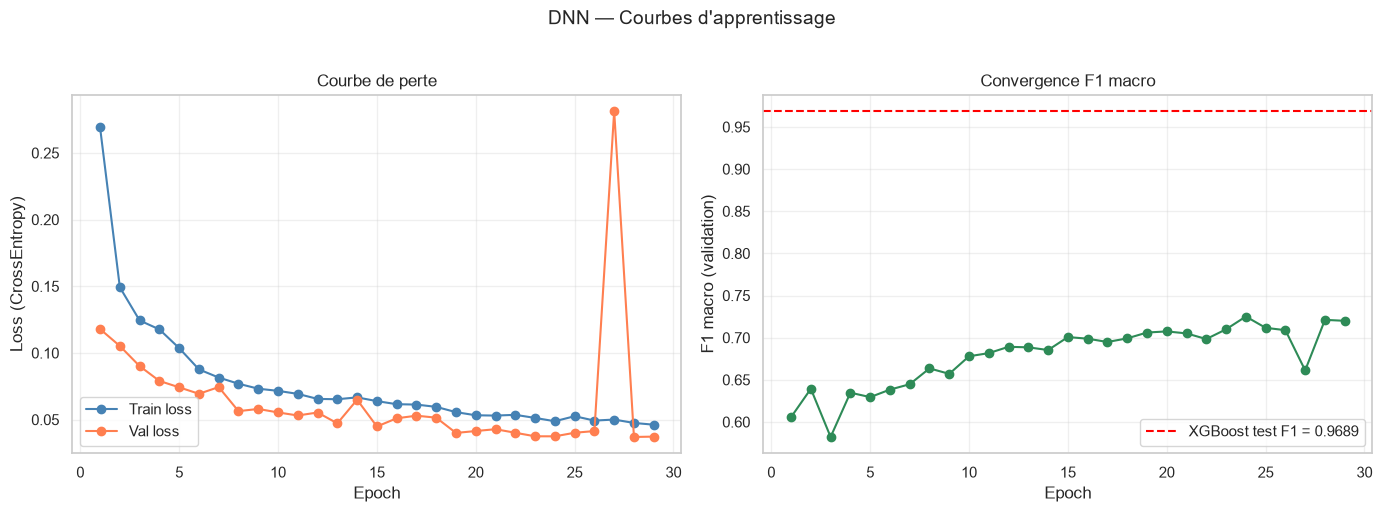

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(history['train_loss']) + 1)

# Loss
axes[0].plot(epochs_range, history['train_loss'], 'o-', label='Train loss', color='steelblue')
axes[0].plot(epochs_range, history['val_loss'], 'o-', label='Val loss', color='coral')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (CrossEntropy)')
axes[0].set_title('Courbe de perte')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# F1
axes[1].plot(epochs_range, history['val_f1'], 'o-', color='seagreen')
axes[1].axhline(0.9689, ls='--', color='red', label='XGBoost test F1 = 0.9689')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1 macro (validation)')
axes[1].set_title('Convergence F1 macro')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('DNN — Courbes d\'apprentissage', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_FIGURES / '06_dnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Évaluation finale sur Test Set

In [9]:
# DataLoader pour test
test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t),
    batch_size=BATCH_SIZE, shuffle=False,
)

# Prédiction + chrono
model.eval()
all_preds = []
t0 = time()
with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(DEVICE)
        logits = model(X_batch)
        preds = logits.argmax(dim=1)
        all_preds.append(preds.cpu().numpy())
y_test_pred_dnn = np.concatenate(all_preds)
dnn_inference_time = time() - t0
dnn_throughput = len(y_test) / dnn_inference_time

# Métriques
dnn_acc = accuracy_score(y_test, y_test_pred_dnn)
dnn_f1_macro = f1_score(y_test, y_test_pred_dnn, average='macro')
dnn_f1_weighted = f1_score(y_test, y_test_pred_dnn, average='weighted')

print(f'⏱️  Inférence : {dnn_inference_time:.2f}s pour {len(y_test):,} échantillons')
print(f'   Débit : {dnn_throughput:,.0f} flows/seconde')
print(f'\n📊 DNN — Test set')
print(f'   Accuracy     : {dnn_acc:.4f}')
print(f'   F1 macro     : {dnn_f1_macro:.4f}')
print(f'   F1 pondéré   : {dnn_f1_weighted:.4f}')

⏱️  Inférence : 3.58s pour 377,682 échantillons
   Débit : 105,410 flows/seconde

📊 DNN — Test set
   Accuracy     : 0.9621
   F1 macro     : 0.7253
   F1 pondéré   : 0.9715


In [10]:
print('📋 DNN — Rapport par classe (test) :\n')
dnn_test_report = classification_report(
    y_test, y_test_pred_dnn,
    target_names=class_names, digits=4
)
print(dnn_test_report)

dnn_test_report_dict = classification_report(
    y_test, y_test_pred_dnn,
    target_names=class_names, output_dict=True,
)
with open(RESULTS_METRICS / 'dnn_test_report.json', 'w') as f:
    json.dump(dnn_test_report_dict, f, indent=2)

📋 DNN — Rapport par classe (test) :

              precision    recall  f1-score   support

      BENIGN     0.9999    0.9548    0.9768    313856
         Bot     0.0453    0.9966    0.0866       292
 Brute Force     0.7628    0.9752    0.8560      1372
        DDoS     0.9856    0.9992    0.9923     19199
         DoS     0.8441    0.9985    0.9148     29037
    PortScan     0.9766    0.9982    0.9873     13604
  Web Attack     0.1519    0.9876    0.2634       322

    accuracy                         0.9621    377682
   macro avg     0.6809    0.9872    0.7253    377682
weighted avg     0.9840    0.9621    0.9715    377682



## 10. Matrice de confusion DNN

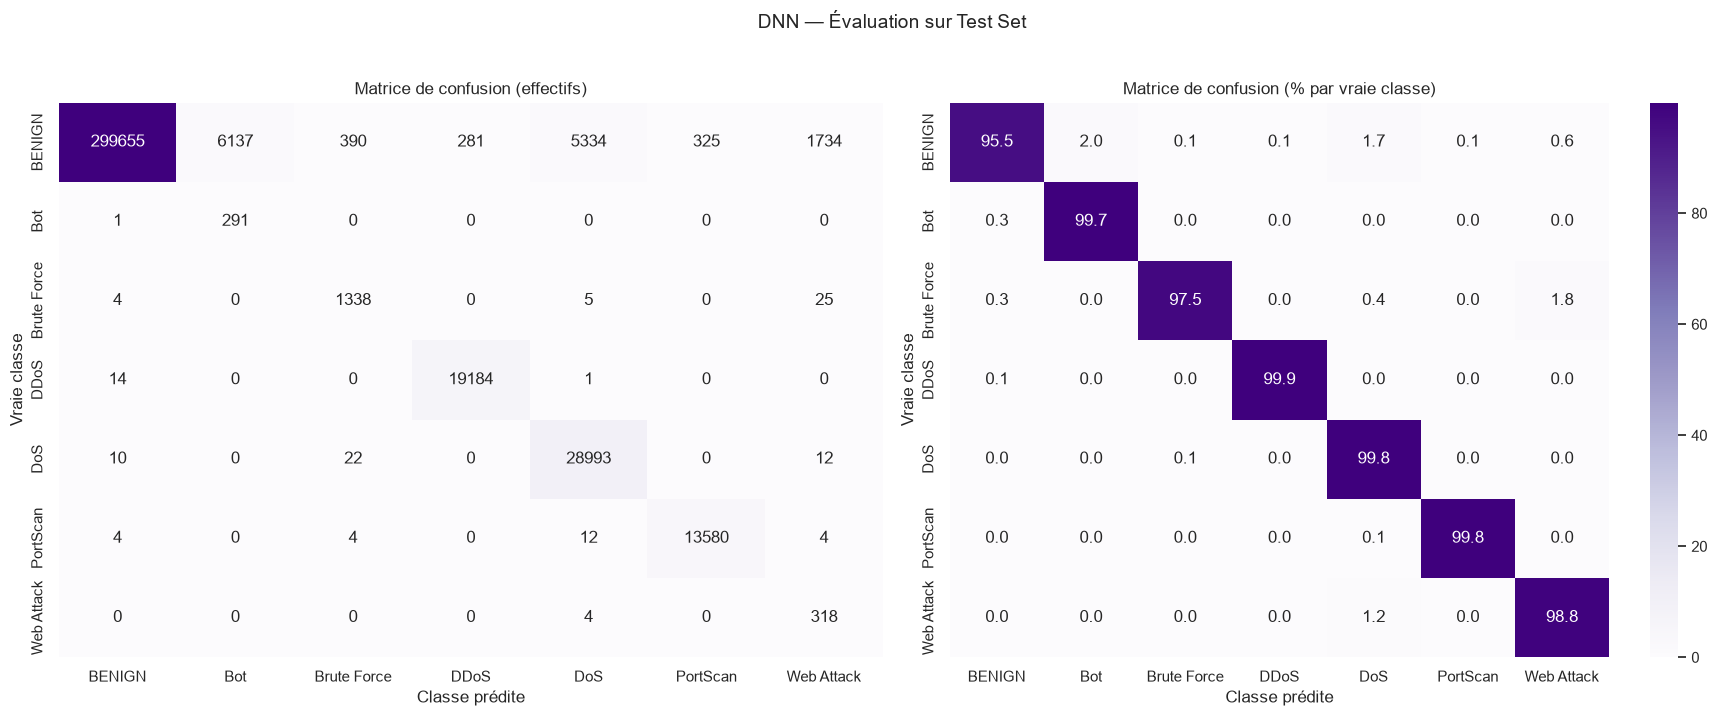

In [11]:
cm = confusion_matrix(y_test, y_test_pred_dnn)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Purples',
    xticklabels=class_names, yticklabels=class_names,
    ax=axes[0], cbar=False,
)
axes[0].set_title('Matrice de confusion (effectifs)')
axes[0].set_xlabel('Classe prédite')
axes[0].set_ylabel('Vraie classe')

sns.heatmap(
    cm_norm, annot=True, fmt='.1f', cmap='Purples',
    xticklabels=class_names, yticklabels=class_names,
    ax=axes[1], cbar=True,
)
axes[1].set_title('Matrice de confusion (% par vraie classe)')
axes[1].set_xlabel('Classe prédite')
axes[1].set_ylabel('Vraie classe')

plt.suptitle('DNN — Évaluation sur Test Set', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_FIGURES / '06_dnn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Comparaison Random Forest vs XGBoost vs DNN

Le grand match à 3.

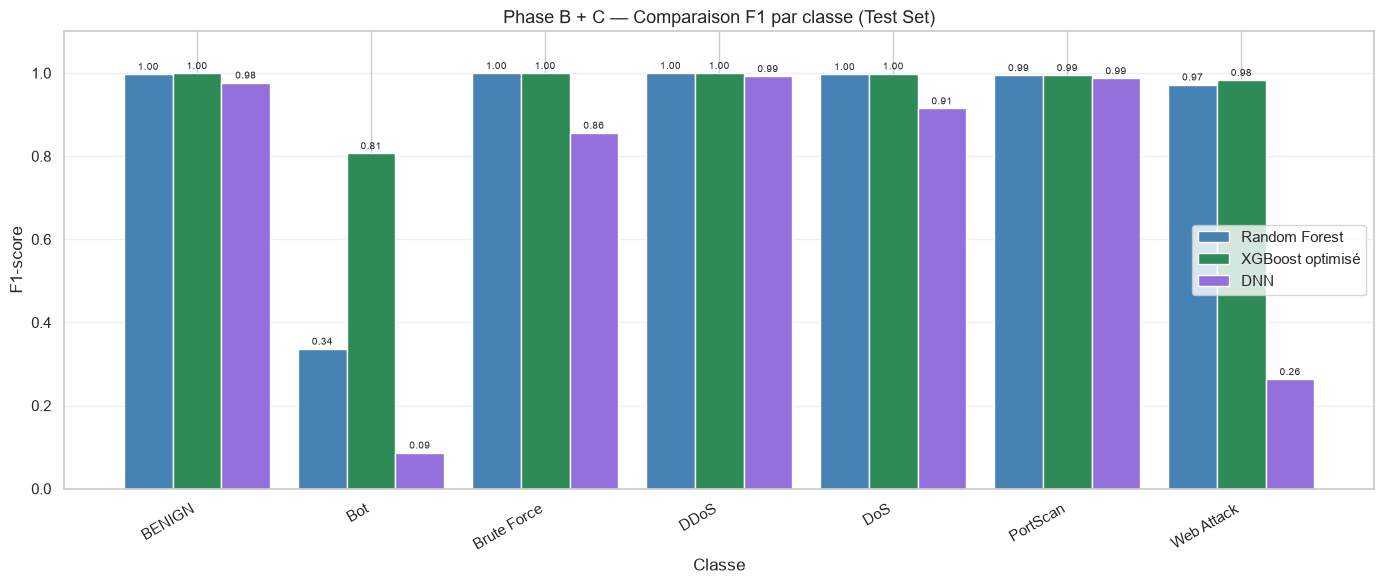

In [12]:
# Recharger les rapports précédents
with open(RESULTS_METRICS / 'rf_test_report.json') as f:
    rf_report = json.load(f)
with open(RESULTS_METRICS / 'xgb_test_report.json') as f:
    xgb_report = json.load(f)

# Graphique F1 par classe — les 3 modèles
rf_f1s = [rf_report[cls]['f1-score'] for cls in class_names]
xgb_f1s = [xgb_report[cls]['f1-score'] for cls in class_names]
dnn_f1s = [dnn_test_report_dict[cls]['f1-score'] for cls in class_names]

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(class_names))
width = 0.28

ax.bar(x - width, rf_f1s, width, label='Random Forest', color='steelblue')
ax.bar(x, xgb_f1s, width, label='XGBoost optimisé', color='seagreen')
ax.bar(x + width, dnn_f1s, width, label='DNN', color='mediumpurple')

ax.set_xlabel('Classe')
ax.set_ylabel('F1-score')
ax.set_title('Phase B + C — Comparaison F1 par classe (Test Set)', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=30, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1.1)

for i, (rf_v, xgb_v, dnn_v) in enumerate(zip(rf_f1s, xgb_f1s, dnn_f1s)):
    ax.text(i - width, rf_v + 0.01, f'{rf_v:.2f}', ha='center', fontsize=7)
    ax.text(i, xgb_v + 0.01, f'{xgb_v:.2f}', ha='center', fontsize=7)
    ax.text(i + width, dnn_v + 0.01, f'{dnn_v:.2f}', ha='center', fontsize=7)

plt.tight_layout()
plt.savefig(RESULTS_FIGURES / '06_rf_xgb_dnn_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Tableau récap des 3 modèles
summary = pd.DataFrame([
    {
        'Modèle': 'Random Forest',
        'Accuracy': rf_report['accuracy'],
        'F1 macro': rf_report['macro avg']['f1-score'],
        'F1 pondéré': rf_report['weighted avg']['f1-score'],
    },
    {
        'Modèle': 'XGBoost (Optuna)',
        'Accuracy': xgb_report['accuracy'],
        'F1 macro': xgb_report['macro avg']['f1-score'],
        'F1 pondéré': xgb_report['weighted avg']['f1-score'],
    },
    {
        'Modèle': 'DNN (PyTorch)',
        'Accuracy': dnn_acc,
        'F1 macro': dnn_f1_macro,
        'F1 pondéré': dnn_f1_weighted,
    },
])
summary_display = summary.set_index('Modèle').round(4)
print('='*70)
print('  COMPARAISON RF / XGBoost / DNN sur Test Set')
print('='*70)
print(summary_display)
print('='*70)

summary.to_csv(RESULTS_METRICS / 'phase_bc_summary.csv', index=False)

  COMPARAISON RF / XGBoost / DNN sur Test Set
                  Accuracy  F1 macro  F1 pondéré
Modèle                                          
Random Forest       0.9962    0.8997      0.9971
XGBoost (Optuna)    0.9990    0.9689      0.9991
DNN (PyTorch)       0.9621    0.7253      0.9715


## 12. Sauvegarde du modèle

In [14]:
model_path = RESULTS_MODELS / 'dnn_pytorch.pt'
torch.save({
    'model_state_dict': model.state_dict(),
    'architecture': {
        'n_features': num_features,
        'n_classes': num_classes,
        'dropout': 0.3,
    },
    'history': history,
    'best_val_f1': best_f1,
}, model_path)

size_mb = model_path.stat().st_size / 1024**2
print(f'✅ Modèle DNN sauvegardé : {model_path}')
print(f'   Taille : {size_mb:.2f} MB')
print(f'   (Bien plus petit qu\'un XGBoost — caractéristique du DL)')

✅ Modèle DNN sauvegardé : ..\results\models\dnn_pytorch.pt
   Taille : 0.25 MB
   (Bien plus petit qu'un XGBoost — caractéristique du DL)


## 🎉 Récapitulatif

Tu viens de construire ton premier modèle deep learning sur des données tabulaires :
- Architecture MLP à 3 couches cachées (256 → 128 → 64)
- Régularisation par BatchNorm + Dropout
- Entraînement avec early stopping et scheduler
- Évaluation rigoureuse sur test set

**Fichiers produits :**
- `results/models/dnn_pytorch.pt` : le modèle entraîné
- `results/models/scaler_dnn.joblib` : le scaler associé
- `results/metrics/dnn_test_report.json` : métriques détaillées
- `results/metrics/phase_bc_summary.csv` : récap des 3 modèles
- 3 figures (courbes apprentissage, matrice de confusion, comparaison)

### Prochaine étape (notebook 07)

**FT-Transformer** : l'architecture deep state-of-the-art pour les données tabulaires (2021). C'est là qu'on saura si le deep learning peut vraiment rivaliser avec XGBoost sur ce dataset.